In [13]:
import pandas as pd
train_df = pd.read_csv("/content/drive/MyDrive/projet covid radiographie pulmonaire/train.csv")
val_df = pd.read_csv("/content/drive/MyDrive/projet covid radiographie pulmonaire/validation.csv")
test_df = pd.read_csv("/content/drive/MyDrive/projet covid radiographie pulmonaire/test.csv")

In [69]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,  
    rotation_range=10,
    zoom_range=0.15,  
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,  
    horizontal_flip=True,
    fill_mode='nearest' 
)


val_train_datagen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=10,
    zoom_range=0.15,  
    width_shift_range=0.2, 
    height_shift_range=0.2,
    shear_range=0.15,  
    horizontal_flip=True, 
    fill_mode='nearest' 
)

k_color_mode = 'grayscale' if COLOR_MODE == 'L' else COLOR_MODE.lower()


train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_gen_df,
    
    x_col='filepath',
    y_col='target',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=k_color_mode,
    class_mode='binary',
    shuffle=True,
    seed=42
)


validation_generator = val_train_datagen.flow_from_dataframe(
    dataframe=val_gen_df,
    
    x_col='filepath',
    y_col='target',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=k_color_mode,
    class_mode='binary',
    shuffle=False,
    seed=42
)


train_generator = val_train_datagen.flow_from_dataframe(
    dataframe=train_gen_df,

    x_col='filepath',
    y_col='target',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=k_color_mode,
    class_mode='binary',
    shuffle=False,
    seed=42
)

print("\nIndices de classe du générateur d'entraînement:")
print(train_generator.class_indices)

Found 8809 validated image filenames belonging to 2 classes.
Found 2186 validated image filenames belonging to 2 classes.
Found 8809 validated image filenames belonging to 2 classes.

Indices de classe du générateur d'entraînement:
{'0': 0, '1': 1}


In [62]:
from tensorflow.keras import layers, models, Input
from tensorflow.keras.layers import Dropout 

# Définir le modèle CNN
model = models.Sequential([
    Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 1)), 
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(62, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    Dropout(0.5), 
    layers.Dense(1, activation='sigmoid') # 'sigmoid' pour la classification binaire
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Afficher un résumé du modèle
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 62)   │        17,918 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 62)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        71,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,165,631 (42.59 MB)

 Trainable params: 11,165,631 (42.59 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
from tensorflow.keras.callbacks import EarlyStopping

# Arrête l'entraînement si val_loss ne s'améliore plus pendant 2 epochs
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [64]:
from tensorflow.keras.callbacks import EarlyStopping

# Entraînement du modèle
epochs = 5 # Vous pouvez ajuster ce nombre

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator), # Utiliser len(train_generator) pour s'assurer que toutes les données sont utilisées
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=len(validation_generator), # Utiliser len(validation_generator) pour s'assurer que toutes les données sont utilisées
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 1092s 4s/step - accuracy: 0.7345 - loss: 0.5508 - val_accuracy: 0.7351 - val_loss: 0.5321
Epoch 2/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 1078s 4s/step - accuracy: 0.7463 - loss: 0.5112 - val_accuracy: 0.7594 - val_loss: 0.4710
Epoch 3/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 1075s 4s/step - accuracy: 0.7623 - loss: 0.4777 - val_accuracy: 0.7681 - val_loss: 0.4708
Epoch 4/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 1157s 4s/step - accuracy: 0.7818 - loss: 0.4516 - val_accuracy: 0.8147 - val_loss: 0.4006
Epoch 5/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 1069s 4s/step - accuracy: 0.7994 - loss: 0.4122 - val_accuracy: 0.8362 - val_loss: 0.3668


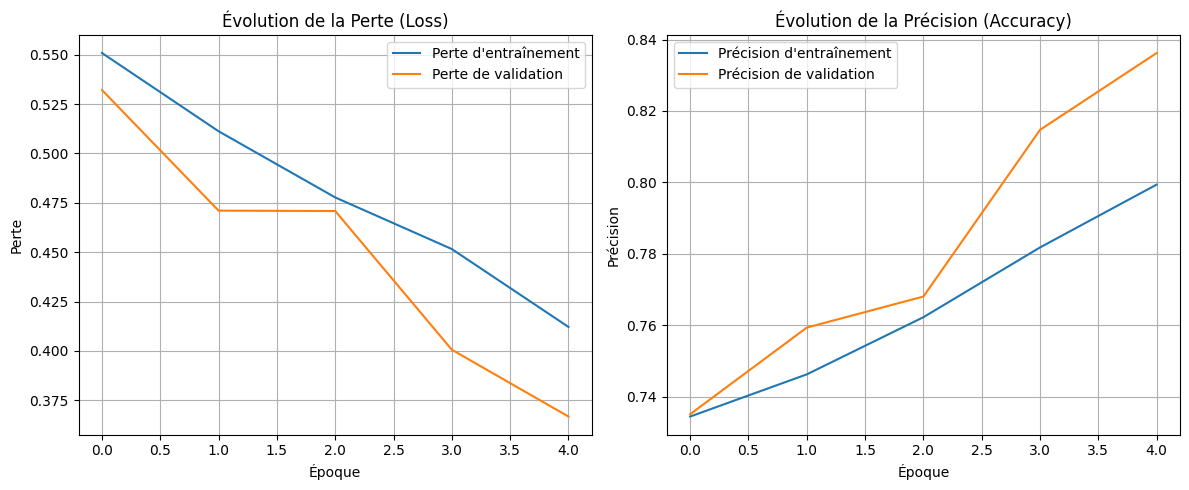

In [65]:
import matplotlib.pyplot as plt

# Afficher les courbes de perte (Loss)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Perte d\'entraînement')
plt.plot(history.history['val_loss'], label='Perte de validation')
plt.title('Évolution de la Perte (Loss)')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()
plt.grid(True)

# Afficher les courbes de précision (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Précision d\'entraînement')
plt.plot(history.history['val_accuracy'], label='Précision de validation')
plt.title('Évolution de la Précision (Accuracy)')
plt.xlabel('Époque')
plt.ylabel('Précision')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

276/276 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step


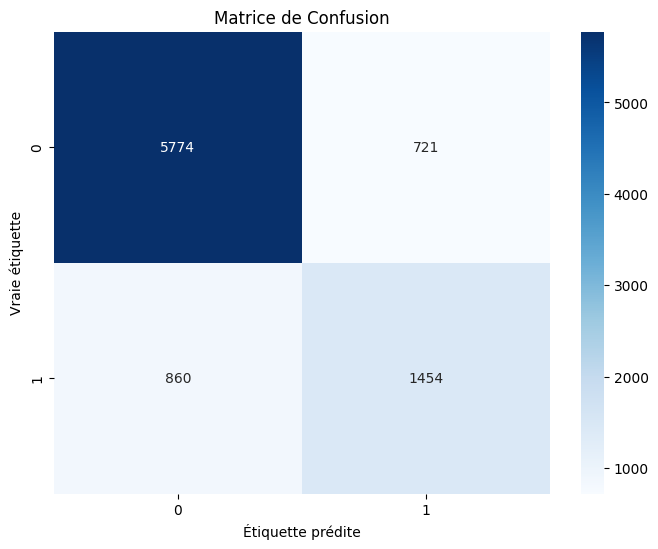


Rapport de Classification :
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      6495
           1       0.67      0.63      0.65      2314

    accuracy                           0.82      8809
   macro avg       0.77      0.76      0.76      8809
weighted avg       0.82      0.82      0.82      8809



In [66]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


train_generator.reset()
predictions = model.predict(train_generator, steps=len(train_generator), verbose=1)
predictions_classes = (predictions > 0.5).astype(int)


true_labels = train_generator.classes

# 3. Calculer la matrice de confusion
cm = confusion_matrix(true_labels, predictions_classes)

# Définir les noms des classes pour une meilleure lisibilité
class_names = list(train_generator.class_indices.keys())

# 4. Visualiser la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion')
plt.ylabel('Vraie étiquette')
plt.xlabel('Étiquette prédite')
plt.show()

# Afficher un rapport de classification détaillé
print("\nRapport de Classification :")
print(classification_report(true_labels, predictions_classes, target_names=class_names))

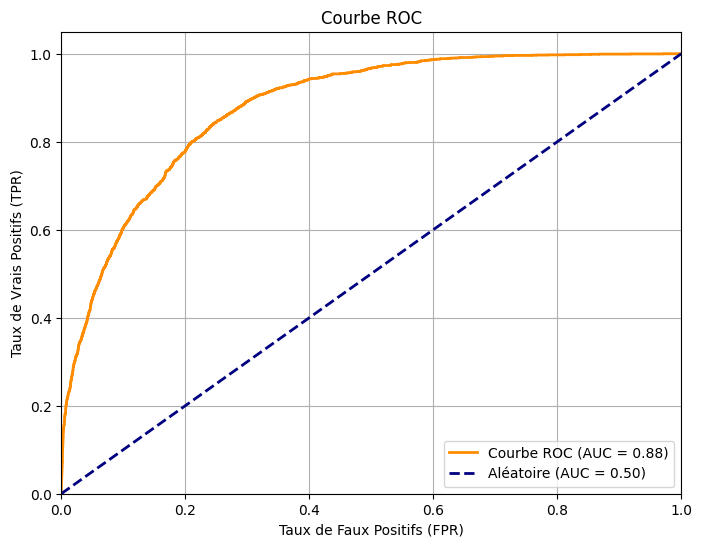

AUC du modèle: 0.88


In [67]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# Calcul de la courbe ROC
fpr, tpr, thresholds = roc_curve(true_labels, predictions)
roc_auc = auc(fpr, tpr)

# Affichage de la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC du modèle: {roc_auc:.2f}")